In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import kagglehub

# Make plots look cleaner
sns.set()

## 1. Load Dataset

In [2]:
# Download latest version from Kaggle
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'craigslist-carstrucks-data' dataset.
Path to dataset files: /kaggle/input/craigslist-carstrucks-data


In [3]:
# Load the dataset
cars_path = os.path.join(path, 'vehicles.csv')
df = pd.read_csv(cars_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


## 2. Check Missing Values

In [4]:
# Count missing values per column
print(df.isna().sum())

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64


## 3. Check Duplicate Rows

In [5]:
# Check for duplicate rows
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")
df[duplicates]

Number of duplicate rows: 0


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date


## 4. Number of Rows and Columns

In [6]:
# Finding number of rows and columns
print("Shape (rows, columns): ", df.shape, "\n")

print("Number of rows:   ", df.shape[0])
print("Number of columns:", df.shape[1])

Shape (rows, columns):  (426880, 26) 

Number of rows:    426880
Number of columns: 26


## 5. Data Types of Columns

In [7]:
# Viewing the data types of columns
df.dtypes

,0
id,int64
url,object
region,object
region_url,object
price,int64
year,float64
manufacturer,object
model,object
condition,object
cylinders,object


In [8]:
# Fix data types
df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce', utc=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['odometer'] = pd.to_numeric(df['odometer'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

df.dtypes

,0
id,int64
url,object
region,object
region_url,object
price,int64
year,float64
manufacturer,object
model,object
condition,object
cylinders,object


## 6. Descriptive Summary Statistics

In [9]:
# Statistical summary of numeric columns
df[['price', 'year', 'odometer']].describe()

,price,year,odometer
count,4.268800e+05,425675.000000,4.224800e+05
mean,7.519903e+04,2011.235191,9.804333e+04
std,1.218228e+07,9.452120,2.138815e+05
min,0.000000e+00,1900.000000,0.000000e+00
25%,5.900000e+03,2008.000000,3.770400e+04
50%,1.395000e+04,2013.000000,8.554800e+04
75%,2.648575e+04,2017.000000,1.335425e+05
max,3.736929e+09,2022.000000,1.000000e+07


In [10]:
# Remove extreme outliers in price (keep $500 - $150,000) and odometer (< 500,000 miles)
df_clean = df[
    (df['price'] >= 500) & (df['price'] <= 150_000) &
    (df['odometer'] < 500_000) &
    (df['year'] >= 1990)
].copy()

print(f"Rows after cleaning: {df_clean.shape[0]}")

Rows after cleaning: 368687


### 6.1. Univariate Analysis

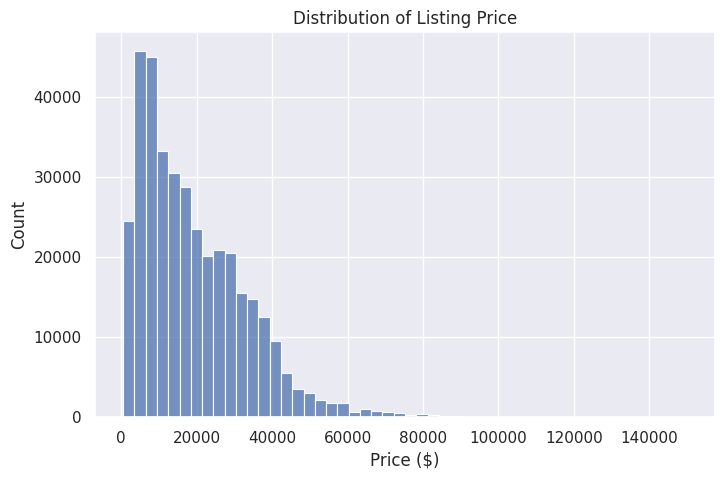

In [11]:
# Distribution of listing price
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['price'], bins=50)
plt.title("Distribution of Listing Price")
plt.xlabel("Price ($)")
plt.show()

### 6.2. Distribution of Odometer Reading

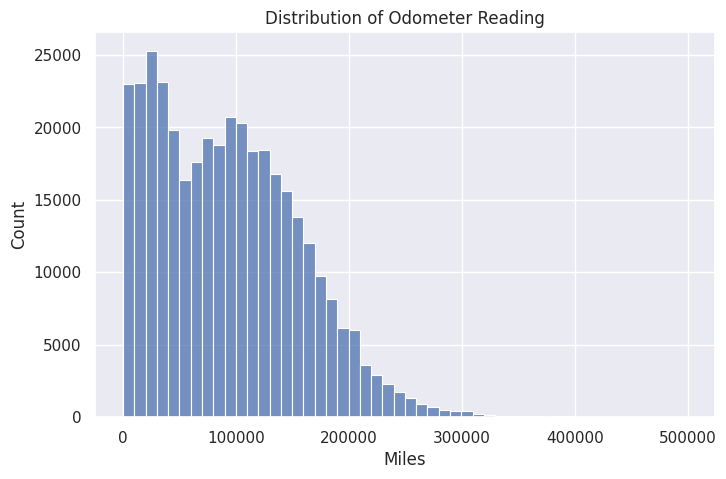

In [12]:
# Distribution of odometer readings
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['odometer'], bins=50)
plt.title("Distribution of Odometer Reading")
plt.xlabel("Miles")
plt.show()

## 7. Bivariate Analysis

### Average Price by Manufacturer

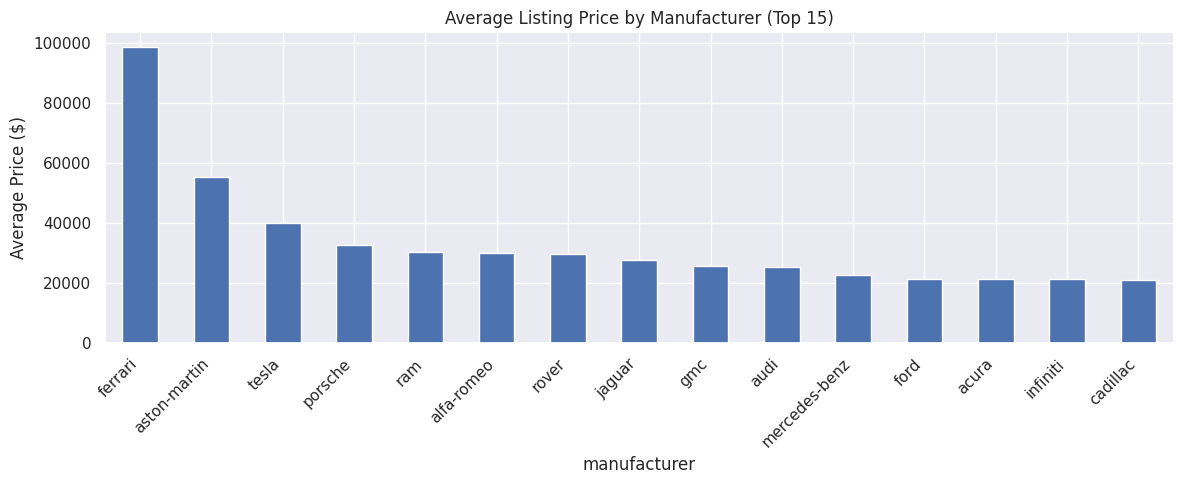

,price
manufacturer,
ferrari,98559.543860
aston-martin,55199.050000
tesla,39866.358084
porsche,32609.253873
ram,30499.875445
alfa-romeo,29877.795181
rover,29570.502902
jaguar,27835.977336
gmc,25652.184448


In [13]:
# Top 15 manufacturers by average listing price
avg_price_by_maker = (
    df_clean.groupby('manufacturer')['price']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 5))
avg_price_by_maker.plot(kind='bar')
plt.title("Average Listing Price by Manufacturer (Top 15)")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

avg_price_by_maker

### Average Price by Vehicle Condition

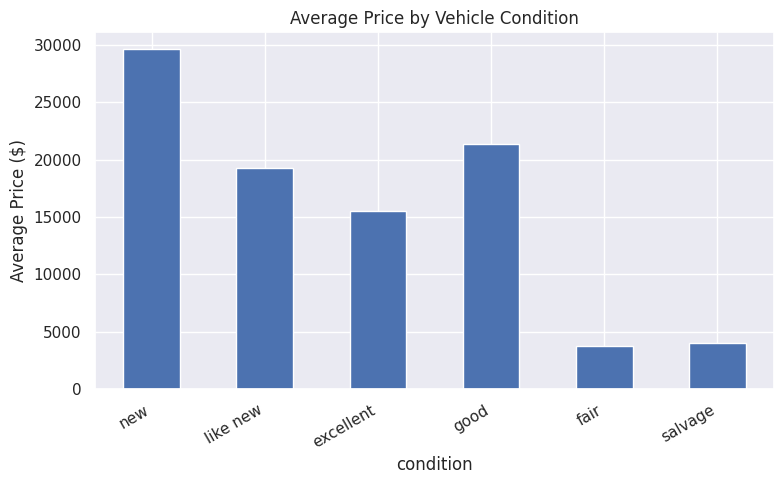

,price
condition,
new,29582.762800
like new,19301.291553
excellent,15499.230259
good,21384.017955
fair,3778.707218
salvage,4074.271762


In [14]:
condition_order = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']

avg_price_by_condition = (
    df_clean.groupby('condition')['price']
    .mean()
    .reindex([c for c in condition_order if c in df_clean['condition'].unique()])
)

plt.figure(figsize=(8, 5))
avg_price_by_condition.plot(kind='bar')
plt.title("Average Price by Vehicle Condition")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

avg_price_by_condition

### Number of Listings by Vehicle Type

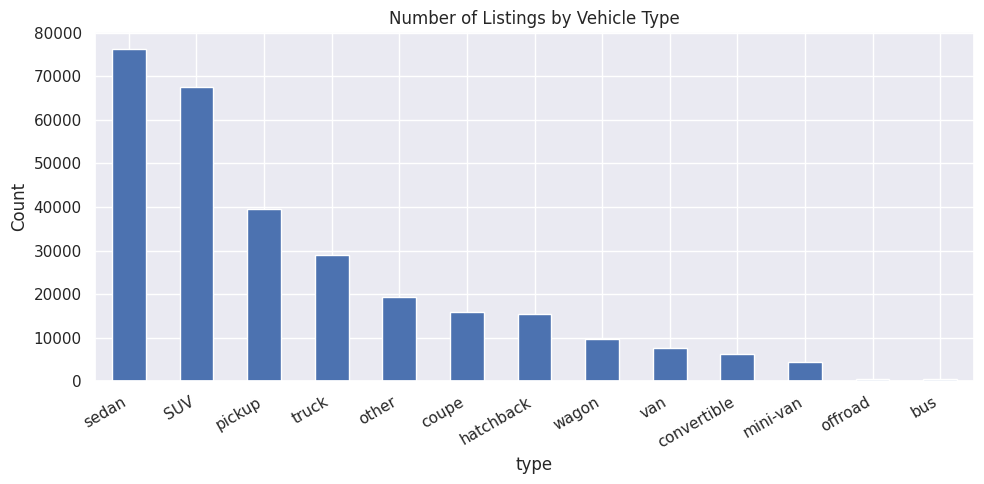

,count
type,
sedan,76266
SUV,67508
pickup,39594
truck,28858
other,19245
coupe,15777
hatchback,15444
wagon,9621
van,7608


In [15]:
listings_by_type = df_clean['type'].value_counts()

plt.figure(figsize=(10, 5))
listings_by_type.plot(kind='bar')
plt.title("Number of Listings by Vehicle Type")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

listings_by_type

### Odometer vs Price Relationship

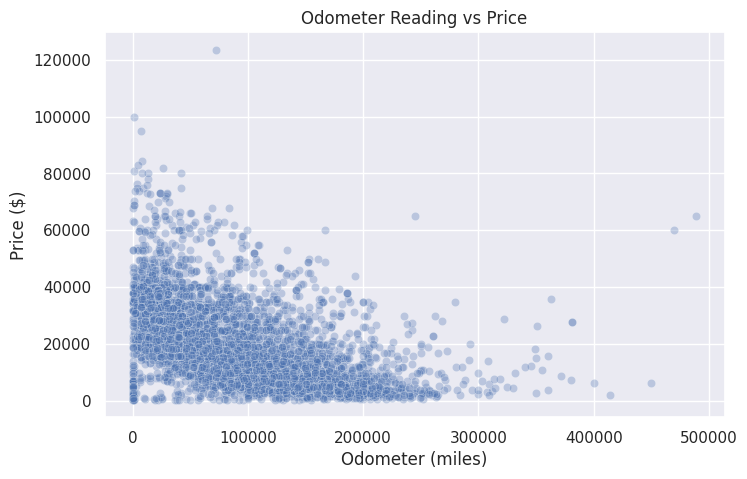

In [16]:
# Sample 5000 rows to keep the scatter plot readable
sample = df_clean.sample(5000, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(x='odometer', y='price', data=sample, alpha=0.3)
plt.title("Odometer Reading vs Price")
plt.xlabel("Odometer (miles)")
plt.ylabel("Price ($)")
plt.show()

### Correlation Matrix

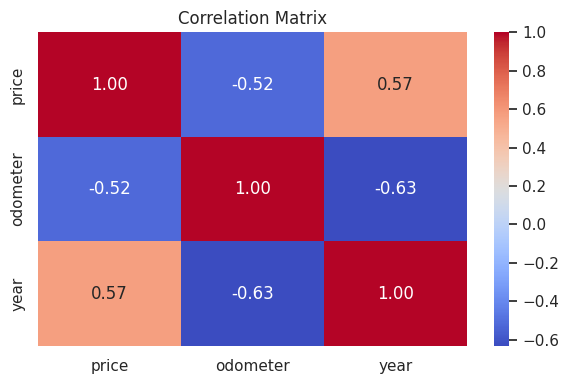

In [17]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df_clean[['price', 'odometer', 'year']].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 8. Time-Based Analysis
### Monthly Listing Volume Trend

/tmp/ipython-input-3362777441.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_clean['month'] = df_clean['posting_date'].dt.to_period('M')


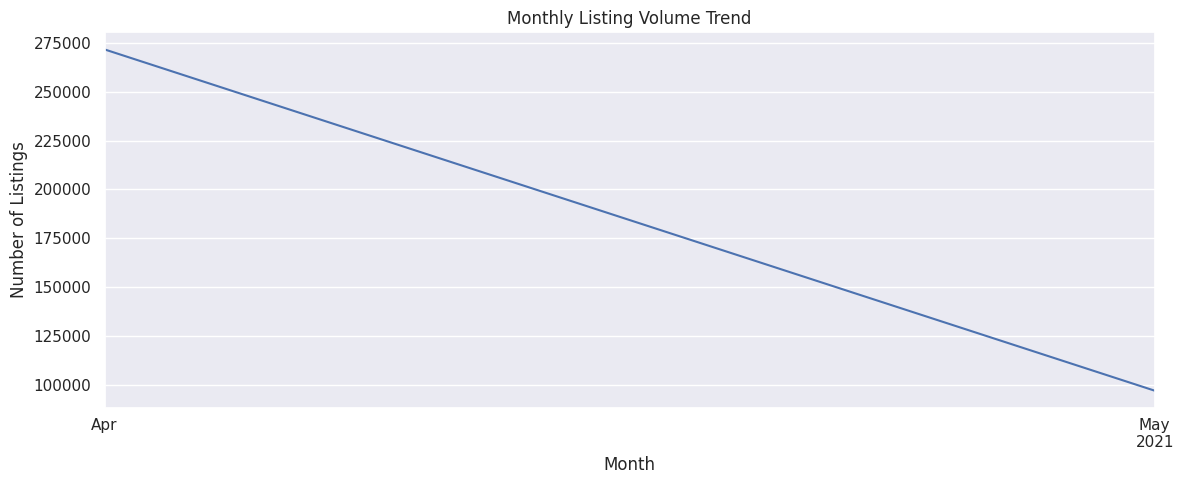

In [18]:
df_clean['month'] = df_clean['posting_date'].dt.to_period('M')

monthly_listings = df_clean.groupby('month')['price'].count()

plt.figure(figsize=(12, 5))
monthly_listings.plot()
plt.title("Monthly Listing Volume Trend")
plt.ylabel("Number of Listings")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

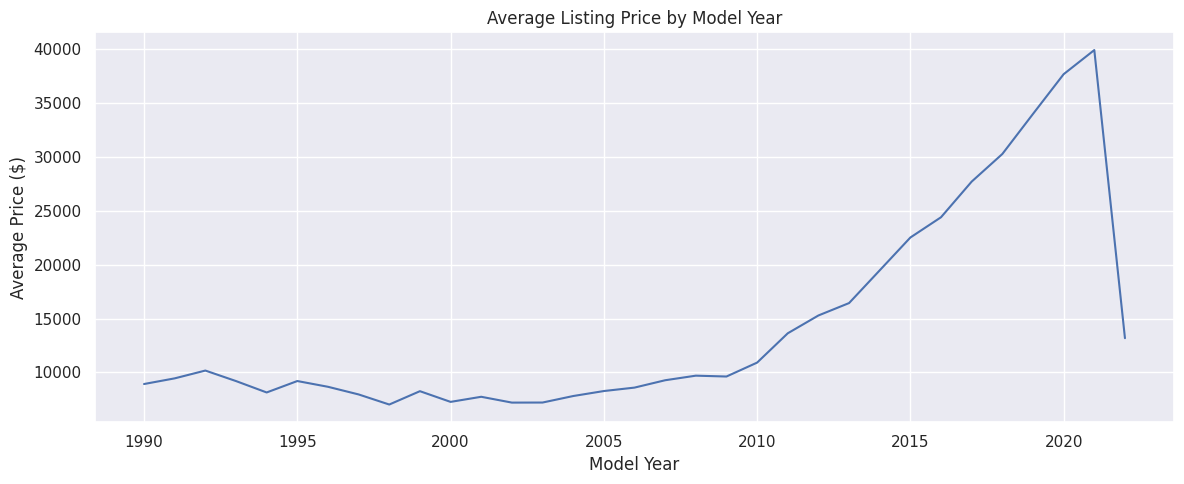

In [19]:
# Average price per model year (price vs age of car)
avg_price_by_year = (
    df_clean.groupby('year')['price']
    .mean()
    .sort_index()
)

plt.figure(figsize=(12, 5))
avg_price_by_year.plot()
plt.title("Average Listing Price by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average Price ($)")
plt.tight_layout()
plt.show()